In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load training data
data = pd.read_csv('data.csv')
X_train = data['height'].values.reshape(-1, 1)
y_train = data['shoe_size'].values
data

,height,shoe_size
0,160,36
1,165,37
2,170,38
3,180,40
4,190,42
5,200,44


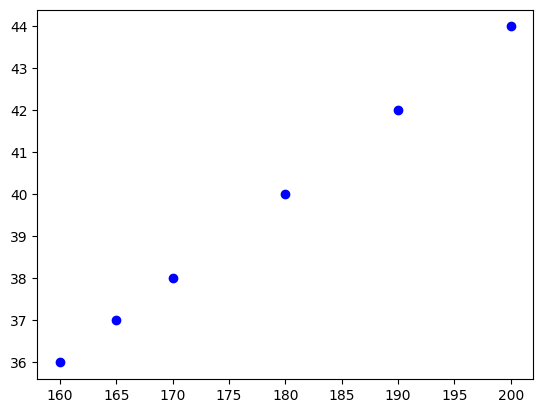

In [3]:
plt.scatter(X_train, y_train, label='Training Data', color='blue')

In [4]:
# Load test data from separate CSV
test_data = pd.read_csv('test_data.csv')
X_test = test_data['height'].values.reshape(-1, 1)
y_test = test_data['shoe_size'].values
test_data

,height,shoe_size
0,175,39
1,185,41
2,195,43


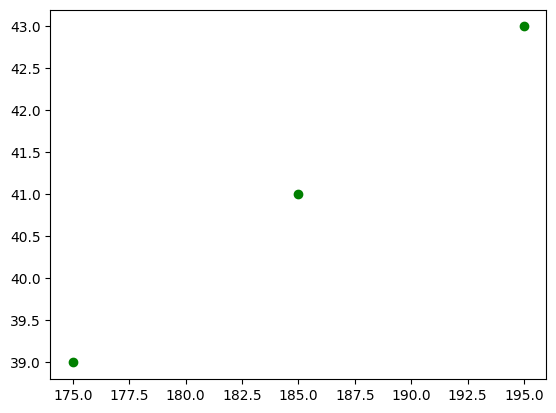

In [5]:
plt.scatter(X_test, y_test, label='Test Data', color='green')

In [6]:
# Linear regression using scikit-learn
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
prediction = model.predict([[167]])
prediction.item()

37.4

In [8]:
# Example predictions using model.predict()
test_heights = [[172], [178], [188]]
predictions = model.predict(test_heights)
predictions

array([38.4, 39.6, 41.6])

In [9]:
print(f"\nPredictions:")
for h, p in zip(test_heights, predictions):
    print(f"Height {h[0]} cm -> Shoe Size {p:.2f}")


Predictions:
Height 172 cm -> Shoe Size 38.40
Height 178 cm -> Shoe Size 39.60
Height 188 cm -> Shoe Size 41.60


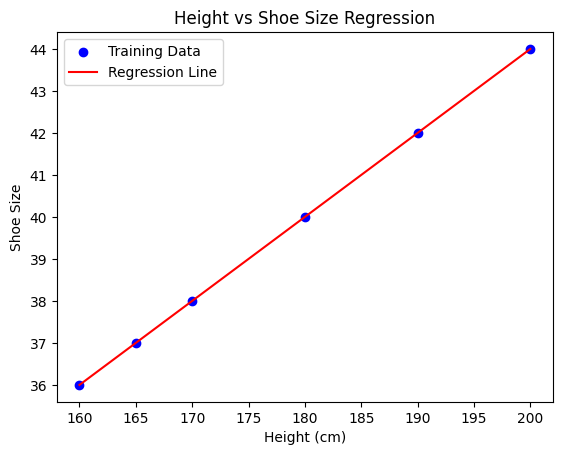

In [10]:
# Plot the training data and regression line
x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
plt.scatter(X_train, y_train, label='Training Data', color='blue')
plt.plot(x_line, model.predict(x_line), label='Regression Line', color='red')
plt.xlabel('Height (cm)')
plt.ylabel('Shoe Size')
plt.legend()
plt.title('Height vs Shoe Size Regression')
plt.show()

In [11]:
# Overview of predicted vs actual on test data
y_pred = model.predict(X_test)
results = pd.DataFrame({
    'Height (cm)': X_test.flatten(),
    'Actual Shoe Size': y_test,
    'Predicted Shoe Size': y_pred.round(2),
    'Difference': abs((y_pred - y_test)).round(2),
})
results = results.sort_values('Height (cm)').reset_index(drop=True)
results
# Calculate key metrics

,Height (cm),Actual Shoe Size,Predicted Shoe Size,Difference
0,175,39,39.0,0.0
1,185,41,41.0,0.0
2,195,43,43.0,0.0


In [12]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [13]:
metrics_df = pd.DataFrame({
    "Metric": ["Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "Mean Absolute Error (MAE)", "R² Score"],
    "Value": [mse, rmse, mae, r2]
})
metrics_df["Value"] = metrics_df["Value"]
metrics_df

,Metric,Value
0,Mean Squared Error (MSE),0.0
1,Root Mean Squared Error (RMSE),0.0
2,Mean Absolute Error (MAE),0.0
3,R² Score,1.0


In [ ]:
# Use provided public_test_data if available; otherwise fallback to existing test_data
if 'public_test_data' in globals():
    my_data = public_test_data.copy()
else:
    my_data = test_data.copy()

# Resolve column names robustly (handles: Hight/height, Shoe size/shoe_size)
col_map = {c.lower().replace(" ", "").replace("_", ""): c for c in my_data.columns}
height_col = col_map.get("hight") or col_map.get("height")
shoe_col = col_map.get("shoesize")

if height_col is None or shoe_col is None:
    raise ValueError(f"Could not find required columns in public data. Found columns: {list(my_data.columns)}")

X_test_public = my_data[[height_col]].values.reshape(-1, 1)
y_test_public = my_data[shoe_col].values

# Predict
y_pred_public = model.predict(X_test_public)

# Analysis table
public_results = pd.DataFrame({
    "Height (cm)": X_test_public.flatten(),
    "Actual Shoe Size": y_test_public,
    "Predicted Shoe Size": np.round(y_pred_public, 2),
    "Difference": np.round(y_pred_public - y_test_public, 2),
    "Abs Difference": np.round(np.abs(y_pred_public - y_test_public), 2)
}).sort_values("Height (cm)").reset_index(drop=True)
plt.figure(figsize=(10, 5))
plt.bar(public_results["Height (cm)"], public_results["Abs Difference"], color='orange', label='Abs Difference')
plt.scatter(public_results["Height (cm)"], public_results["Actual Shoe Size"], color='blue', label='Actual', zorder=5)
plt.scatter(public_results["Height (cm)"], public_results["Predicted Shoe Size"], color='red', label='Predicted', zorder=5)
plt.xlabel('Height (cm)')
plt.ylabel('Shoe Size')
plt.title('Actual vs Predicted Shoe Size')
plt.legend()
plt.tight_layout()
plt.show()
public_results


NameError: name 'public_test_data' is not defined